# HealthConnect Clinic Experience Lab
## Week 5: Exploratory Analysis, KPI Development & Business Analysis

During the execution of my Week 4 task, the HealthConnect appointment dataset was reviewed to understand it's structure, quality, and relevance to the clinic's appointment attendance problem.

Initial analysis shows several variables that may be useful for investigating no-show behaviour, including previous no-shows, reminder activity, booking lead time, appointment timing, appointment type, distance to the clinic, and waiting time.

Week 5 moves from planning into practical analysis. The focus is therefore to prepare the data, calculate selected KPIs, conduct exploratory analysis, identify meaningful patterns and translate those findings into practical business recommendations.

**Problem defined:** appointment no-shows and inefficient appointment utilisation.

**Resources:** the HealthConnect appointment dataset and data dictionary

**Main Limitations:** some missing values, associations should not be automatically as causation, and synthetic data.

## Data Preparation
### Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Loading Datasets

In [4]:
df = pd.read_csv(r"C:\Users\BADA\Downloads\Data Analysis\Analyst lab\HealthConnect_Clinic_Experience_Lab\Data\Raw\HealthConnect_Appointment_Data.csv")

### Exploratory Analysis

In [5]:
df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


In [6]:
df.shape

(5000, 18)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

In [8]:
df.describe(include="object")

,appointment_id,patient_id,gender,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,reminder_sent,reminder_channel,appointment_outcome
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,3634,5000
unique,5000,1696,3,6,4,593,545,7,3,2,3,3
top,HC-00001,P-1399,Female,65+,General Consultation,8/24/2025,3/14/2026,Wednesday,Morning,Yes,SMS,No-Show
freq,1,9,2488,1241,2086,20,18,737,2227,3634,2000,2423


In [9]:
df["patient_id"].nunique()

1696

The dataset contains 5,000 appointment records and 18 variables. There are 1,696 unique patient IDs. The data dictionary identifies appointment_id as the unique appointment identifier while patient_id may appear across multiple appointments.

### Checking Missing Values

In the supplied dataset, the important missing-value pattern is:

In [10]:
df.isnull().sum()

appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
appointment_outcome         0
dtype: int64

In [11]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().sum()/len(df)) * 100
})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary

,missing_count,missing_percentage
reminder_channel,1366,27.32
distance_to_clinic_km,90,1.80
waiting_time_minutes,60,1.20


However, reminder_channel needs special treatment. The data dictionary explicitly says the reminder channel should be None when no reminder was sent. 


The dataset contains 1,366 appointments with reminder_sent = "No" and correspondingly 1,366 blank reminder channels. Therefore, those blanks should not automatically be labelled data-quality errors.

To further test the relationship between reminder_sent field and reminder_channel field:

In [12]:
pd.crosstab(
    df["reminder_sent"],
    df["reminder_channel"].fillna("None")
)

reminder_channel,Email,None,SMS,WhatsApp
reminder_sent,,,,
No,0,1366,0,0
Yes,533,0,2000,1101


Missing values in reminder_channel are structurally expected for appointments where no reminder was sent and therefore do not necessarily represent incomplete records.

### Checking For Duplicates

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["appointment_id"].duplicated().sum()

np.int64(0)

In [15]:
df["appointment_id"].nunique()


5000

In [16]:
df["patient_id"].nunique()

1696

The supplied data has 5,000 unique appointment IDs, with no duplicate appointment IDs, while patients can appear in multiple records as intended.

### Validating Categorical Variables

In [17]:
for col in [
    "gender",
    "age_group",
    "appointment_type",
    "appointment_day",
    "appointment_time",
    "reminder_sent",
    "reminder_channel",
    "appointment_outcome"
]:
    print("\n", col)
    print(df[col].value_counts(dropna=False))


 gender
gender
Female               2488
Male                 2404
Prefer not to say     108
Name: count, dtype: int64

 age_group
age_group
65+      1241
35-44     819
55-64     800
45-54     793
25-34     783
18-24     564
Name: count, dtype: int64

 appointment_type
appointment_type
General Consultation       2086
Follow-up                  1421
Specialist Consultation     900
Diagnostic Test             593
Name: count, dtype: int64

 appointment_day
appointment_day
Wednesday    737
Sunday       737
Friday       728
Saturday     724
Monday       701
Tuesday      689
Thursday     684
Name: count, dtype: int64

 appointment_time
appointment_time
Morning      2227
Afternoon    2094
Evening       679
Name: count, dtype: int64

 reminder_sent
reminder_sent
Yes    3634
No     1366
Name: count, dtype: int64

 reminder_channel
reminder_channel
SMS         2000
NaN         1366
WhatsApp    1101
Email        533
Name: count, dtype: int64

 appointment_outcome
appointment_outcome
No-Show    

### Validating Dates

converting booking_dates and appointment_dates from object datatype to standard Pandas datetime64 format

In [18]:
df["booking_date"] = pd.to_datetime(df["booking_date"])
df["appointment_date"] = pd.to_datetime(df["appointment_date"])

There should not normally be an appointment scheduled before its booking date. To confirm, we verfiy:

In [19]:
(df["appointment_date"] < df["booking_date"]).sum()

np.int64(0)

No appointments were scheduled earlier than it's booking date

**To test the supplied booking_lead_days:**

In [20]:
calculated_lead_days = (
    df["appointment_date"] - df["booking_date"]
).dt.days

(df["booking_lead_days"] != calculated_lead_days).sum()

np.int64(0)

The data dictionary identifies booking_lead_days as both provided and derivable, this data-quality check verifies that.

### Validating Historical appointment fields
The data dictionary says: previous_no_shows cannot exceed historical appointments.


In [21]:
(df["previous_no_shows"] > df["previous_appointments"]).sum()

np.int64(0)

In [22]:
df[["previous_appointments", "previous_no_shows"]].describe()

,previous_appointments,previous_no_shows
count,5000.000000,5000.000000
mean,3.013800,0.544200
std,1.741211,0.746832
min,0.000000,0.000000
25%,2.000000,0.000000
50%,3.000000,0.000000
75%,4.000000,1.000000
max,11.000000,5.000000


### Validating age and age group fields

In [23]:
df["age"].describe()


count    5000.000000
mean       48.794800
std        18.138547
min        18.000000
25%        33.000000
50%        49.000000
75%        64.000000
max        80.000000
Name: age, dtype: float64

In [24]:
df["age_group"].value_counts()

age_group
65+      1241
35-44     819
55-64     800
45-54     793
25-34     783
18-24     564
Name: count, dtype: int64

To check whether the supplied age groups correspond to age.

In [25]:
pd.crosstab(df["age_group"], pd.cut(
    df["age"],
    bins=[17,24,34,44,54,64,200],
    labels=["18-24","25-34","35-44","45-54","55-64","65+"]
))

age,18-24,25-34,35-44,45-54,55-64,65+
age_group,,,,,,
18-24,564,0,0,0,0,0
25-34,0,783,0,0,0,0
35-44,0,0,819,0,0,0
45-54,0,0,0,793,0,0
55-64,0,0,0,0,800,0
65+,0,0,0,0,0,1241


### Create a cleaned analytical dataset

In [26]:
df_clean = df.copy()

df_clean["booking_date"] = pd.to_datetime(df_clean["booking_date"])
df_clean["appointment_date"] = pd.to_datetime(df_clean["appointment_date"])

df_clean["reminder_channel"] = (
    df_clean["reminder_channel"].fillna("No Reminder")
)

In [27]:
df_clean.to_csv(
    r"C:/Users/BADA/Downloads/Data Analysis/Analyst lab/HealthConnect_Clinic_Experience_Lab/Data/Processed/HealthConnect_Appointment_Data_Cleaned.csv",
    index=False
)

### Defining the correct population for your no-show analysis

There are three appointment outcomes:

- Attended
- No-Show
- Cancelled

The dataset contains all three categories. For most attendance/no-show rate calculations, we define:

**Eligible completed appointment opportunities =
Attended + No-Show**

In [28]:
attendance_df = df_clean[
    df_clean["appointment_outcome"].isin(["Attended", "No-Show"])
].copy()

In [29]:
attendance_df["is_no_show"] = (
    attendance_df["appointment_outcome"] == "No-Show"
).astype(int)

### Selecting core KPIs

**Calculate KPI 1 — Overall No-Show Rate**

In [30]:
no_show_rate = attendance_df["is_no_show"].mean() * 100
print(f"Overall No-Show Rate (Excluding Cancellations): {no_show_rate:.2f}%")

Overall No-Show Rate (Excluding Cancellations): 51.15%


**Business question:** What proportion of eligible scheduled appointments result in a no-show?

Approximately 51.15% of eligible appointments resulted in a no-show, providing HealthConnect with a baseline against which future attendance-improvement initiatives could be assessed.

**Calculate KPI 2 — No-show rate by previous history**

In [31]:
attendance_df["previous_no_show_history"] = np.where(
    attendance_df["previous_no_shows"] > 0,
    "Previous No-Show",
    "No Previous No-Show"
)

In [32]:
history_kpi = (
    attendance_df
    .groupby("previous_no_show_history")["is_no_show"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

history_kpi["no_show_rate"] = history_kpi["mean"] * 100

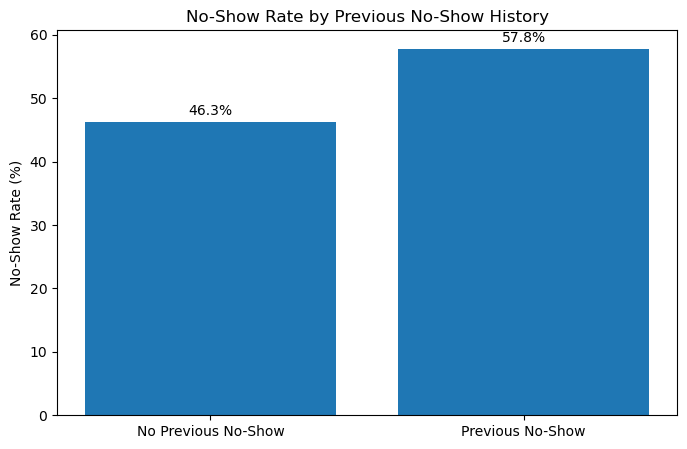

In [33]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    history_kpi["previous_no_show_history"],
    history_kpi["no_show_rate"]
)

plt.bar_label(bars, fmt='%.1f%%', padding=3)

plt.ylabel("No-Show Rate (%)")
plt.title("No-Show Rate by Previous No-Show History")
plt.show()

People who’ve missed appointments before are much more likely to do it again. If someone has a history of skipping out, their chances of flaking on a future appointment are around 57.8%, and they are 11.5% more likely to miss it than someone who has always shown up. Essentially, past habits are among the strongest indicators of whether someone will actually turn up.

### Calculate KPI 3 — Reminder status

In [34]:
reminder_stat_kpi = (
    attendance_df
    .groupby("reminder_sent")["is_no_show"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

reminder_stat_kpi["no_show_rate"] = reminder_stat_kpi["mean"] * 100
reminder_stat_kpi

,reminder_sent,count,sum,mean,no_show_rate
0,No,1285,702,0.546304,54.630350
1,Yes,3452,1721,0.498552,49.855156


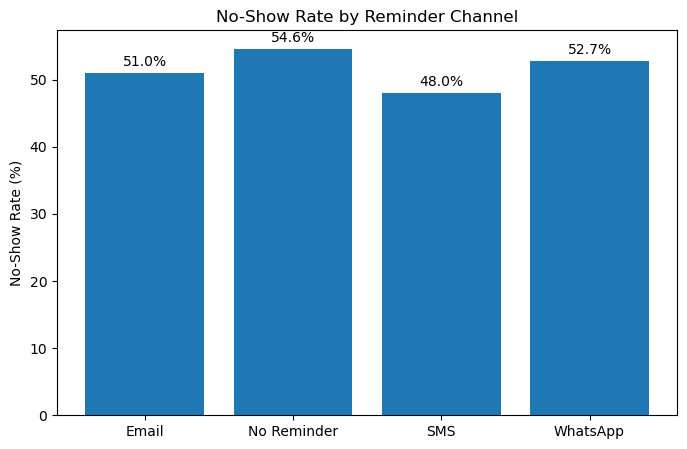

In [35]:
channel_kpi = (
    attendance_df
    .groupby("reminder_channel")["is_no_show"]
    .agg(["count", "mean"])
    .reset_index()
)

channel_kpi["no_show_rate"] = channel_kpi["mean"] * 100

plt.figure(figsize=(8,5))
bars = plt.bar(
    channel_kpi["reminder_channel"], 
    channel_kpi["no_show_rate"]
)

plt.bar_label(bars, fmt='%.1f%%', padding=3)

plt.ylabel("No-Show Rate (%)")
plt.title("No-Show Rate by Reminder Channel")
plt.show()

Appointments associated with No reminders record the highest no-show rate (54.6%) and WhatsApp reminders recorded a higher no-show rate (52.7%) within this dataset. Further investigation is needed to verify this claim.

### Calculate KPI 4 — Booking lead time

In [36]:
# 1. Use float('inf') to catch everything over 60 days
bins = [-1, 7, 14, 30, 60, float('inf')] 

labels = [
    "0-7 days",
    "8-14 days",
    "15-30 days",
    "31-60 days",
    "60+ days"
]

attendance_df["lead_time_group"] = pd.cut(
    attendance_df["booking_lead_days"],
    bins=bins,
    labels=labels
) 

lead_time_kpi = (
    attendance_df
    .groupby("lead_time_group", observed=False)["is_no_show"]
    .agg(["count", "mean"])
    .reset_index()
)

lead_time_kpi["no_show_rate"] = lead_time_kpi["mean"] * 100

lead_time_kpi

,lead_time_group,count,mean,no_show_rate
0,0-7 days,604,0.294702,29.470199
1,8-14 days,574,0.351916,35.191638
2,15-30 days,1265,0.455336,45.533597
3,31-60 days,2294,0.639494,63.949433
4,60+ days,0,NaN,NaN


People with bookings within 0–7 days tend to be the most reliable in the dataset. Only about 29.5% of them miss their appointments, and with 604 bookings. We can observe a trend in which there is a high portion of patient that miss their appointments, with increasing distance between their booking date and appointments. People with booking dates from 31-60 days are tend to be the most unreliable with about 63.9% of them missing their appointments.

### Calculate KPI 5 — Distance

In [37]:
distance_bins = [0, 5, 10, 20, np.inf]
distance_labels = [
    "<5 km",
    "5-10 km",
    "10-20 km",
    "20+ km"
]

attendance_df["distance_group"] = pd.cut(
    attendance_df["distance_to_clinic_km"],
    bins=distance_bins,
    labels=distance_labels,
    include_lowest=True
)

distance_kpi = (
    attendance_df
    .groupby("distance_group", observed=False)["is_no_show"]
    .agg(["count", "mean"])
    .reset_index()
)

distance_kpi["no_show_rate"] = distance_kpi["mean"] * 100
distance_kpi

,distance_group,count,mean,no_show_rate
0,<5 km,1103,0.486854,48.685403
1,5-10 km,1595,0.493417,49.341693
2,10-20 km,1578,0.522814,52.281369
3,20+ km,375,0.605333,60.533333


## A More Thorough Exploration of the Dataset

### Analysing appointment outcomes

In [41]:
outcome_summary = (
    df_clean["appointment_outcome"]
    .value_counts()
    .to_frame("appointments")
)

outcome_summary["percentage"] = (
    outcome_summary["appointments"] / len(df_clean) * 100
)
outcome_summary

,appointments,percentage
appointment_outcome,,
No-Show,2423,48.46
Attended,2314,46.28
Cancelled,263,5.26


### Analysing Days of week

In [44]:
day_analysis = (
    attendance_df
    .groupby("appointment_day")["is_no_show"]
    .agg(["count", "mean"])
    .reset_index()
)

day_analysis["no_show_rate"] = day_analysis["mean"] * 100
day_analysis

,appointment_day,count,mean,no_show_rate
0,Friday,696,0.487069,48.706897
1,Monday,655,0.531298,53.129771
2,Saturday,683,0.496340,49.633968
3,Sunday,704,0.528409,52.840909
4,Thursday,644,0.520186,52.018634
5,Tuesday,662,0.489426,48.942598
6,Wednesday,693,0.528139,52.813853


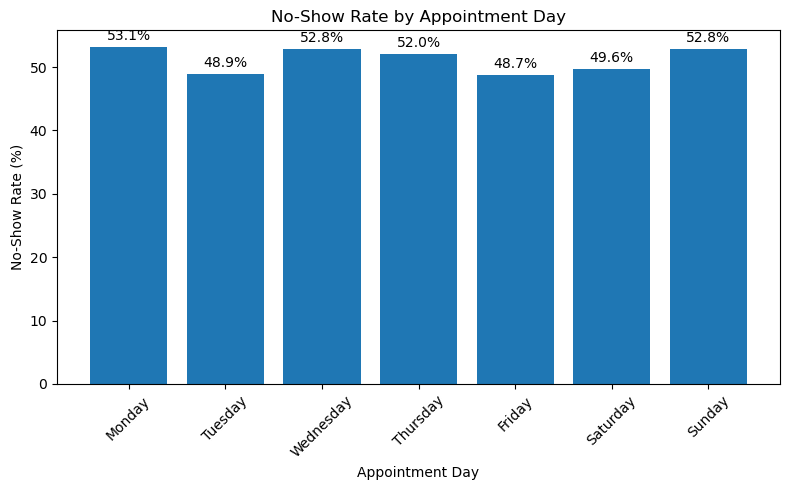

In [45]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_analysis["appointment_day"] = pd.Categorical(
    day_analysis["appointment_day"], categories=day_order, ordered=True
)
day_analysis = day_analysis.sort_values("appointment_day")

plt.figure(figsize=(8, 5))
bars = plt.bar(
    day_analysis["appointment_day"], day_analysis["no_show_rate"]
)

plt.bar_label(bars, fmt="%.1f%%", padding=3)
plt.ylabel("No-Show Rate (%)")
plt.xlabel("Appointment Day")
plt.title("No-Show Rate by Appointment Day")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Friday recorded a no-show rate of 48.7% (lowest), compared with 53% on Monday (highest).

### Analyzing Appointment time

For appointment time analysis, the main question is:

Does the no-show rate differ between Morning, Afternoon, and Evening appointments?

No-show rates are compared, rather than just the number of no-shows, because one time period may simply have more appointments than another.

In [46]:
attendance_df = df_clean[
    df_clean["appointment_outcome"].isin(["Attended", "No-Show"])
].copy()

attendance_df["is_no_show"] = (
    attendance_df["appointment_outcome"] == "No-Show"
).astype(int)



In [47]:
attendance_df["appointment_time"].value_counts()

appointment_time
Morning      2116
Afternoon    1979
Evening       642
Name: count, dtype: int64

### Calculating no-show rate by appointment time

In [48]:
time_analysis = (
    attendance_df
    .groupby("appointment_time")["is_no_show"]
    .agg(
        appointments="count",
        no_shows="sum",
        no_show_rate="mean"
    )
    .reset_index()
)

time_analysis["no_show_rate"] = (
    time_analysis["no_show_rate"] * 100
)

time_analysis

,appointment_time,appointments,no_shows,no_show_rate
0,Afternoon,1979,1013,51.187468
1,Evening,642,338,52.647975
2,Morning,2116,1072,50.661626


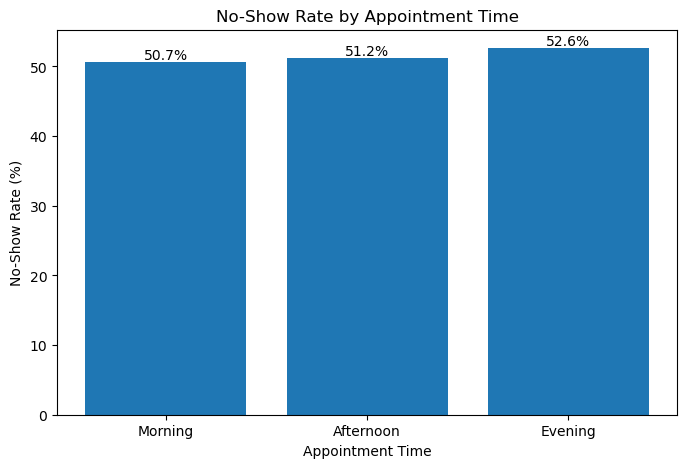

In [50]:
time_order = ["Morning", "Afternoon", "Evening"]

time_analysis["appointment_time"] = pd.Categorical(
    time_analysis["appointment_time"],
    categories=time_order,
    ordered=True
)

time_analysis = time_analysis.sort_values("appointment_time")

plt.figure(figsize=(8, 5))

bars = plt.bar(
    time_analysis["appointment_time"],
    time_analysis["no_show_rate"]
)

plt.title("No-Show Rate by Appointment Time")
plt.xlabel("Appointment Time")
plt.ylabel("No-Show Rate (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

The chart compares the no-show rate across Morning, Afternoon and Evening appointment periods. Evening appointments recorded the highest observed no-show rate at 52.6%, compared with 51.2% for Afternoon and 50.7% for Morning appointments. This suggests that appointment timing may be associated with attendance behaviour and could be considered when reviewing scheduling and reminder strategies.

In [51]:
time_analysis[
    ["appointment_time", "appointments", "no_shows", "no_show_rate"]
]

,appointment_time,appointments,no_shows,no_show_rate
2,Morning,2116,1072,50.661626
0,Afternoon,1979,1013,51.187468
1,Evening,642,338,52.647975


Evening appointments recorded the highest no-show rate; however, they represented a smaller appointment volume than Morning and Afternoon periods. Therefore, while Evening appointments appear to have weaker attendance, interventions should also consider the absolute number of missed appointments across each period.

### Analyzing Appintment Type

In [52]:
type_analysis = (
    attendance_df.groupby("appointment_type")["is_no_show"]
    .agg(appointments="count", no_shows="sum", no_show_rate="mean")
    .reset_index()
)
type_analysis["no_show_rate"] *= 100
type_analysis.sort_values("no_show_rate", ascending=False).round(2)

,appointment_type,appointments,no_shows,no_show_rate
1,Follow-up,1344,728,54.17
0,Diagnostic Test,567,295,52.03
3,Specialist Consultation,846,427,50.47
2,General Consultation,1980,973,49.14


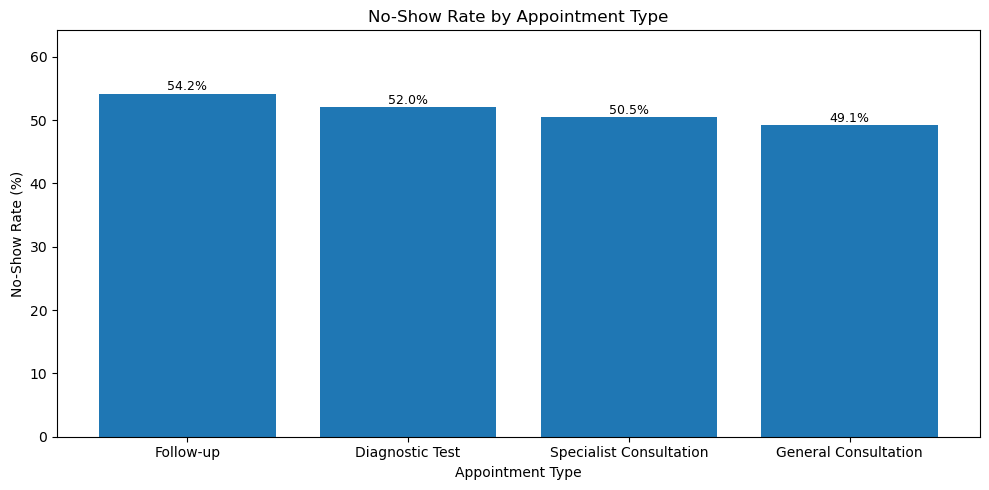

In [57]:
plot_df = type_analysis.sort_values("no_show_rate", ascending=False)
plt.figure(figsize=(10, 5))
bars = plt.bar(plot_df["appointment_type"], plot_df["no_show_rate"])
plt.title("No-Show Rate by Appointment Type")
plt.xlabel("Appointment Type")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=0, ha="center")
plt.ylim(0, max(plot_df["no_show_rate"]) + 10)
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.5,
        f"{h:.1f}%",
        ha="center",
        fontsize=9,
    )
plt.tight_layout()
plt.show()

Follow-up appointments have the highest observed no-show rate among the four appointment categories. This segment may warrant closer review because it combines a relatively high rate with substantial appointment volume.

### Analyzing Age Groups

In [58]:
age_order = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
age_analysis = (
    attendance_df.groupby("age_group")["is_no_show"]
    .agg(appointments="count", no_shows="sum", no_show_rate="mean")
    .reset_index()
)
age_analysis["no_show_rate"] *= 100
age_analysis["age_group"] = pd.Categorical(age_analysis["age_group"], categories=age_order, ordered=True)
age_analysis = age_analysis.sort_values("age_group")
age_analysis.round(2)

,age_group,appointments,no_shows,no_show_rate
0,18-24,540,283,52.41
1,25-34,750,397,52.93
2,35-44,770,396,51.43
3,45-54,746,381,51.07
4,55-64,766,406,53.00
5,65+,1165,560,48.07


Differences across age groups are relatively moderate compared with the stronger patterns in previous no-show history and booking lead time. Demographic results should be used for descriptive understanding, not discriminatory decision-making.

### Analyzing Waiting-time

In [59]:
waiting_df = attendance_df.dropna(subset=["waiting_time_minutes"]).copy()
waiting_df["waiting_time_group"] = pd.cut(
    waiting_df["waiting_time_minutes"],
    bins=[0, 15, 30, 45, 60, np.inf],
    labels=["0-15 min", "16-30 min", "31-45 min", "46-60 min", "60+ min"],
    include_lowest=True
)
waiting_analysis = (
    waiting_df.groupby("waiting_time_group", observed=False)["is_no_show"]
    .agg(appointments="count", no_shows="sum", no_show_rate="mean")
    .reset_index()
)
waiting_analysis["no_show_rate"] *= 100
waiting_analysis.round(2)

,waiting_time_group,appointments,no_shows,no_show_rate
0,0-15 min,1012,505,49.90
1,16-30 min,2329,1216,52.21
2,31-45 min,1212,602,49.67
3,46-60 min,123,61,49.59
4,60+ min,3,2,66.67


 Most waiting-time groups show similar no-show rates. The `60+ min` group contains very few eligible records, so its percentage is unstable and should not be treated as a strong business finding. Waiting time therefore appears less informative in this initial analysis than booking lead time, previous history or distance.

### Analyzing Cancellation

In [61]:
cancelled_df = df_clean[df_clean["appointment_outcome"] == "Cancelled"].copy()

# Calculate the overall cancellation rate percentage
cancellation_rate = (len(cancelled_df) / len(df_clean)) * 100
print(f"Cancellation rate: {cancellation_rate:.2f}%")

cancel_by_type = (
    df_clean.assign(
        is_cancelled=(df_clean["appointment_outcome"] == "Cancelled").astype(int)
    )
    .groupby("appointment_type")["is_cancelled"]
    .agg(appointments="count", cancellations="sum", cancellation_rate="mean")
    .reset_index()
)
cancel_by_type["cancellation_rate"] *= 100
cancel_by_type.sort_values("cancellation_rate", ascending=False).round(2)

Cancellation rate: 5.26%


,appointment_type,appointments,cancellations,cancellation_rate
3,Specialist Consultation,900,54,6.00
1,Follow-up,1421,77,5.42
2,General Consultation,2086,106,5.08
0,Diagnostic Test,593,26,4.38


Cancellations are retained as an operational outcome but excluded from the main no-show denominator. This avoids treating patients who cancelled as if they failed to attend.

## Consolidated Key Findings

In [69]:
findings_table = pd.DataFrame([
    ["Overall no-show baseline", f"{no_show_rate:.1f}%", "Missed appointments represent a major share of eligible attendance appointments."],
    ["Previous no-show history", f"{history_kpi.loc[history_kpi['previous_no_show_history']=='Previous No-Show','no_show_rate'].iloc[0]:.1f}% vs {history_kpi.loc[history_kpi['previous_no_show_history']=='No Previous No-Show','no_show_rate'].iloc[0]:.1f}%", "Prior attendance history is strongly associated with current no-show behaviour."],
    ["Reminder status", f"{reminder_stat_kpi.loc[reminder_stat_kpi['reminder_sent']=='No','no_show_rate'].iloc[0]:.1f}% without vs {reminder_stat_kpi.loc[reminder_stat_kpi['reminder_sent']=='Yes','no_show_rate'].iloc[0]:.1f}% with reminder", "Appointments with reminders show a lower observed no-show rate."],
    ["Booking lead time", f"{lead_time_kpi.loc[lead_time_kpi['lead_time_group'].astype(str)=='31-60 days','no_show_rate'].iloc[0]:.1f}% for 31-60 days", "Longer lead times are associated with substantially higher no-show rates."],
    ["Distance", f"{distance_kpi.loc[distance_kpi['distance_group'].astype(str)=='20+ km','no_show_rate'].iloc[0]:.1f}% for 20+ km", "Long-distance appointments show the highest observed no-show rate."],
    ["Appointment type", f"{type_analysis.loc[type_analysis['appointment_type']=='Follow-up','no_show_rate'].iloc[0]:.1f}% for Follow-up", "Follow-up appointments show the highest no-show rate among service categories."],
    ["Appointment time", f"{time_analysis.loc[time_analysis['appointment_time'].astype(str)=='Evening','no_show_rate'].iloc[0]:.1f}% in Evening", "Time-of-day differences exist but are comparatively modest."],
], columns=["Finding", "Evidence", "Business Meaning"])

findings_table

,Finding,Evidence,Business Meaning
0,Overall no-show baseline,51.2%,Missed appointments represent a major share of...
1,Previous no-show history,57.8% vs 46.3%,Prior attendance history is strongly associate...
2,Reminder status,54.6% without vs 49.9% with reminder,Appointments with reminders show a lower obser...
3,Booking lead time,63.9% for 31-60 days,Longer lead times are associated with substant...
4,Distance,60.5% for 20+ km,Long-distance appointments show the highest ob...
5,Appointment type,54.2% for Follow-up,Follow-up appointments show the highest no-sho...
6,Appointment time,52.6% in Evening,Time-of-day differences exist but are comparat...


### Main analytical story
The strongest patterns in this initial analysis relate to **previous no-show history**, **booking lead time**, and **distance to the clinic**. Reminder status also shows a potentially useful difference. Appointment time, day, age group and waiting time provide context but generally show smaller or less stable differences.

## Business Recommendations

Based on the observed patterns, HealthConnect could consider the following actions for testing and refinement:

1. **Prioritise confirmation for appointments with previous no-show history.**  
   These appointments have a materially higher observed no-show rate. HealthConnect could test additional confirmation steps or earlier outreach for this segment.

2. **Introduce reconfirmation for long-lead appointments.**  
   No-show rates increase sharply as booking lead time increases. Appointments scheduled several weeks in advance could receive a reconfirmation message closer to the appointment date.

3. **Review and test the reminder strategy.**  
   Appointments with reminders show a lower observed no-show rate. HealthConnect could assess reminder timing and channel effectiveness through a controlled pilot rather than assuming the observed association is causal.

4. **Consider access challenges for patients travelling longer distances.**  
   The highest-distance group records the highest no-show rate. Where operationally feasible, the clinic could explore clearer travel information, confirmation outreach or other administrative support for long-distance patients.

5. **Review follow-up appointment workflows.**  
   Follow-up appointments show the highest observed no-show rate among appointment categories. HealthConnect could investigate whether follow-up scheduling, communication or timing differs from other services.

6. **Use rates together with appointment volume when prioritising action.**  
   A high percentage in a very small group may be less operationally important than a moderately high rate affecting a large number of appointments.

These recommendations should be treated as hypotheses for operational testing rather than guaranteed interventions.

## Limitations and Risks

- The dataset is fictional and anonymised, so findings should not be generalised directly to a real clinic.
- The analysis is observational; association does not establish causation.
- `distance_to_clinic_km` and `waiting_time_minutes` contain limited missing values. Records were excluded only from analyses requiring the relevant variable.
- Reminder assignment may not be random. Differences between reminded and non-reminded appointments may reflect other patient or appointment characteristics.
- The supplied variables may not capture all real-world drivers of attendance, such as transport reliability, work schedules, socioeconomic constraints or acute changes in health.
- Some grouped categories can contain small sample sizes. Small groups should not be over-interpreted.
- Demographic findings should remain descriptive and should not be used to make discriminatory assumptions about individual patients.
- `waiting_time_minutes` should be interpreted cautiously if its exact timing/availability relative to the attendance decision is not clearly established.

## Dashboard Preparation Table

In [75]:
from pathlib import Path

export_tables = {
    "history_kpi": history_kpi,
    "reminder_stat_kpi": reminder_stat_kpi,
    "lead_time_kpi": lead_time_kpi,
    "distance_kpi": distance_kpi,
    "time_analysis": time_analysis,
    "day_analysis": day_analysis,
    "type_analysis": type_analysis,
    "age_analysis": age_analysis,
    "waiting_analysis": waiting_analysis,
}

output_dir = Path('.') 

for name, table in export_tables.items():
   
    path = output_dir / f"{name}.csv"
    table.to_csv(path, index=False)

print(f"Supporting KPI tables exported to: {output_dir.absolute()}")

Supporting KPI tables exported to: C:\Users\BADA


## Proposed Week 6 Focus

Week 6 should build on the initial findings by:

- refining the strongest analyses and checking whether key patterns persist across subgroups;
- reviewing possible interactions, such as booking lead time by reminder status or appointment type;
- refining the Power BI dashboard and business narrative;
- validating KPI definitions and calculation logic;
- incorporating genuine cross-track feedback;
- testing whether proposed recommendations are supported consistently across relevant segments;
- preparing a clearer final analytical story for subsequent project stages.

## Conclusion

This Week 5 analysis moved the HealthConnect project from planning into practical implementation. The appointment data was prepared and validated, cancellation handling was defined, five core KPIs were calculated, and exploratory analysis was conducted across patient history, reminders, booking lead time, distance, appointment timing, appointment type, age group and waiting time.

The clearest observed patterns are associated with **previous no-show history, longer booking lead times and greater distance to the clinic**, while reminder status also shows a potentially useful difference. These findings provide HealthConnect with evidence-based areas to investigate when designing appointment-confirmation and patient-support strategies.

The results should remain interpreted as **descriptive associations** within the supplied fictional dataset. They provide a strong foundation for dashboard development, cross-track collaboration and deeper analysis in the next stage of the project.